<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/LateFusionBCNN_test/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [1]:
# in a setup cell
!pip install blitz-bayesian-pytorch --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.4 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
# print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using device:", device)



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [3]:
def bandpass_filter_ecg(ecg, fs, lowcut=0.5, highcut=40.0, order=4):

    ecg = np.asarray(ecg)

    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    b, a = butter(order, [low, high], btype="band")

    # axis=0 means we filter along time when ecg has shape (num_samples, num_leads)
    ecg_filtered = filtfilt(b, a, ecg, axis=0)

    return ecg_filtered

In [4]:
def train_bayesian_classifier(model, train_loader, test_loader=None, epochs=30,
                               learning_rate=1e-3, sample_nbr=3, verbose=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    n_train = len(train_loader.dataset)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0.0, 0, 0

        for X_batch, demog_batch, y_batch in train_loader:
            X_batch, demog_batch, y_batch = X_batch.to(device), demog_batch.to(device), y_batch.to(device)
            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)

            optimizer.zero_grad()

            # Average NLL over multiple weight samples (Monte Carlo over the variational posterior)
            nll = 0.0
            logits_accum = 0.0
            for _ in range(sample_nbr):
                logits = model(X_batch, demog_batch)
                nll += criterion(logits, y_batch)
                logits_accum += logits.detach()
            nll = nll / sample_nbr
            logits_mean = logits_accum / sample_nbr

            kl = model.nn_kl_divergence()          # total KL across all Bayesian layers
            loss = nll + kl / n_train               # ELBO = NLL + KL/N

            loss.backward()
            optimizer.step()

            b = X_batch.shape[0]
            total_loss += nll.item() * b
            correct += (torch.argmax(logits_mean, dim=1) == y_batch).sum().item()
            total += b

        train_loss, train_acc = total_loss / total, correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_bayesian_classifier(model, test_loader, criterion, sample_nbr=sample_nbr)
            scheduler.step(test_loss)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
            # if verbose:
            #     print(f"Epoch {epoch+1}/{epochs}: train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
            #           f"test loss={test_loss:.4f}, test acc={test_acc:.4f}, lr={optimizer.param_groups[0]['lr']:.2e}")

    return history


def evaluate_bayesian_classifier(model, data_loader, criterion=None, sample_nbr=10):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, demog_batch, y_batch in data_loader:
            X_batch, demog_batch, y_batch = X_batch.to(device), demog_batch.to(device), y_batch.to(device)

            probs_accum = 0.0
            for _ in range(sample_nbr):
                logits = model(X_batch, demog_batch)
                probs_accum += torch.softmax(logits, dim=1)
            probs_mean = probs_accum / sample_nbr

            loss = criterion(torch.log(probs_mean + 1e-8), y_batch)  # approx NLL on averaged probs
            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(probs_mean, dim=1) == y_batch).sum().item()
            total += b

    return total_loss / total, correct / total


## 4. Helper Function: Plot Training Curves


In [5]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [8]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')

Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1


#initial definitions - ECGs
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
# print(X_ts.shape)
# print(y_ts.shape)

#for averaging
fs = 250

X_filt = np.array([
    bandpass_filter_ecg(x, fs)
    for x in X
])

X_ts = np.swapaxes(X_filt, 1, 2)
# print(X_ts.shape)
# print(y_ts.shape)


#initial definitions - metrics
y_metric = np.array(labels[:1000])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:1000])
# print(demog_metric[50])



## 11. Visualize Example Time Series



## 12. Create PyTorch DataLoaders for Time Series


In [9]:

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# =====================================================================
# 1. PREPROCESSING THE DEMOGRAPHIC DATA
# =====================================================================

# Convert your raw demographic array/list into a clean Pandas DataFrame
columns = ['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']
df_demog = pd.DataFrame(demog_metric, columns=columns)

# One-hot encode the categorical text features ('gender' and 'race')
# dummy_na=True ensures missing strings get their own column for the imputer to see
df_encoded = pd.get_dummies(df_demog, columns=['sex', 'race_ethnicity'], dummy_na=True, drop_first=False)

# All columns in df_encoded are now numerical and should be scaled before imputation.
# The previous `continuous_cols` list was incorrect because 'sex' and 'race_ethnicity'
# no longer exist after one-hot encoding.
scaler = StandardScaler()
# Apply scaler to all columns of the df_encoded DataFrame
df_encoded_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns, index=df_encoded.index) #ask

# Run KNN Imputer across the combined scaled and encoded columns
imputer = KNNImputer(n_neighbors=3) #looks at 3 other rows with similar data and takes their average for the missing value
demographic_clean = imputer.fit_transform(df_encoded_scaled)

# =====================================================================
# 2. PYTORCH TENSOR AND DATA LOADER SETUP
# =====================================================================

# Dynamically pull the exact number of features after one-hot encoding
fused_demog_dim = demographic_clean.shape[1] #ask
# print(f"-> Dynamic Demographic Input Dimension: {fused_demog_dim}")

TEST_SPLIT_PERCENTAGE = .10

y_ts_test = y_ts[-int((len(y_ts)*TEST_SPLIT_PERCENTAGE)):]
y_ts_training = y_ts[:-int((len(y_ts)*TEST_SPLIT_PERCENTAGE))]

X_ts_test = X_ts[-int((len(X_ts)*TEST_SPLIT_PERCENTAGE)):]
X_ts_training = X_ts[:-int((len(X_ts)*TEST_SPLIT_PERCENTAGE))]

X_demog_test = demographic_clean[-int((len(X_ts)*TEST_SPLIT_PERCENTAGE)):]
X_demog_training = demographic_clean[:-int((len(X_ts)*TEST_SPLIT_PERCENTAGE)):]



# Convert your underlying arrays straight into PyTorch device tensors
X_ts_tensor = torch.tensor(X_ts_training, dtype=torch.float32, device=device)
X_demog_tensor = torch.tensor(X_demog_training, dtype=torch.float32, device=device)
y_ts_tensor = torch.tensor(y_ts_training, dtype=torch.long, device=device)


# Zip all three parallel data structures into one Dataset
ts_dataset = TensorDataset(X_ts_tensor, X_demog_tensor, y_ts_tensor)

# Generate reproducible train/test splits
train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Build out your final multi-modal DataLoaders
ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True)
ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [10]:
import torch
import torch.nn as nn
from blitz.modules import BayesianLinear, BayesianConv1d
from blitz.utils import variational_estimator

# Global prior settings (scale-mixture prior, applied to all BLiTZ layers)
PRIOR_SIGMA_1 = 2.0
PRIOR_SIGMA_2 = 0.0025
PRIOR_PI = 1.0
POSTERIOR_RHO_INIT = -5.0   # tighter initial posterior variance -> more stable start


class BayesianDemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.fc1 = BayesianLinear(
            input_dim, 32,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )
        self.relu = nn.ReLU()

        self.fc2 = BayesianLinear(
            32, output_dim,
            prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
            posterior_rho_init=POSTERIOR_RHO_INIT
        )

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return x


@variational_estimator
class BayesianLateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        def bconv(in_c, out_c, k, p):
            return BayesianConv1d(
                in_c, out_c, kernel_size=k, padding=p,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        def blinear(in_f, out_f):
            return BayesianLinear(
                in_f, out_f,
                prior_sigma_1=PRIOR_SIGMA_1, prior_sigma_2=PRIOR_SIGMA_2, prior_pi=PRIOR_PI,
                posterior_rho_init=POSTERIOR_RHO_INIT
            )

        self.conv1 = bconv(in_channels, 16, 15, 7)
        self.pool1 = nn.AvgPool1d(kernel_size=10)   # 2500 -> 250

        self.conv2 = bconv(16, 32, 9, 4)
        self.pool2 = nn.AvgPool1d(kernel_size=10)   # 250 -> 25

        self.conv3 = bconv(32, 32, 5, 2)
        self.gap   = nn.AdaptiveAvgPool1d(1)        # 25 -> 1

        self.relu = nn.ReLU()

        self.demog_features = BayesianDemographicMLP(input_dim=demog_dim, output_dim=16)

        self.fc_out1 = blinear(32 + 16, 32)
        self.fc_out2 = blinear(32, num_classes)

    def forward(self, ts_input, demog_input):
        x = self.relu(self.conv1(ts_input))
        x = self.pool1(x)

        x = self.relu(self.conv2(x))
        x = self.pool2(x)

        x = self.relu(self.conv3(x))
        x = self.gap(x)
        ts_emb = torch.flatten(x, start_dim=1)          # [B, 32]

        demog_emb = self.demog_features(demog_input)    # [B, 16]

        fused = torch.cat((ts_emb, demog_emb), dim=1)   # [B, 48]
        out = self.relu(self.fc_out1(fused))
        out = self.fc_out2(out)
        return out


## 14. Train the 1D CNN


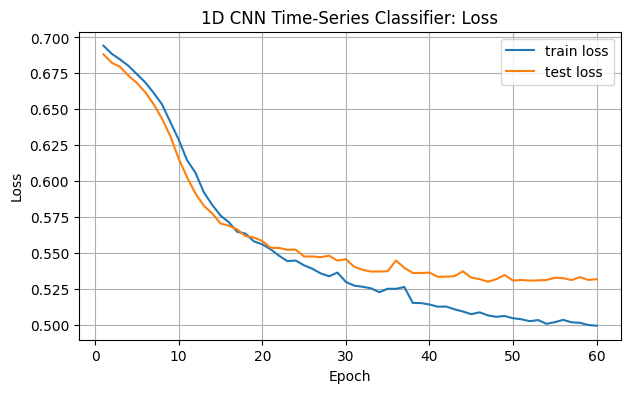

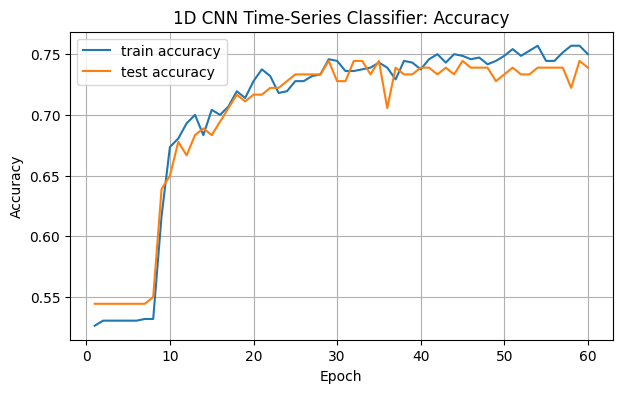

In [11]:
# =====================================================================
# 3. INITIALIZE AND TRAIN THE MODEL
# =====================================================================

bayes_model = BayesianLateFusionHeartDiseaseModel(
    sequence_length=2500, num_classes=2, in_channels=12, demog_dim=fused_demog_dim
)

ts_history = train_bayesian_classifier(
    bayes_model, ts_train_loader, ts_test_loader, epochs=60, learning_rate=1e-4, sample_nbr=3
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")

In [ ]:
bayes_model.eval()
X_batch, demog_batch, y_batch = next(iter(ts_test_loader))

n_samples = 50
preds = torch.stack([
    torch.softmax(bayes_model(X_batch.to(device), demog_batch.to(device)), dim=1)
    for _ in range(n_samples)
])  # [n_samples, batch, num_classes]


mean_probs = preds.mean(dim=0)   # predicted probability
std_probs  = preds.std(dim=0)    # epistemic uncertainty — how much the model disagrees with itself

predicted_class = mean_probs.argmax(dim=1)              # final prediction
confidence = mean_probs.max(dim=1).values                # P(predicted class)
uncertainty = std_probs.gather(1, predicted_class.unsqueeze(1)).squeeze(1)  # std on the predicted class


# for i in range(len(y_batch)):
#     print(f"Sample {i}: true={y_batch[i].item()}, pred={predicted_class[i].item()}, "
#           f"confidence={confidence[i].item():.3f}, uncertainty (std)={uncertainty[i].item():.3f}")

In [21]:
X_ts_test_tensor = torch.tensor(X_ts_test, dtype=torch.float32, device=device)
X_demog_test_tensor = torch.tensor(X_demog_test, dtype=torch.float32, device=device)
y_ts_test_tensor = torch.tensor(y_ts_test, dtype=torch.long, device=device)

ts_full_test_dataset = TensorDataset(X_ts_test_tensor, X_demog_test_tensor, y_ts_test_tensor)
ts_full_test_loader = DataLoader(ts_full_test_dataset, batch_size=10, shuffle=False)

test_loss, test_acc = evaluate_bayesian_classifier(bayes_model, ts_full_test_loader, sample_nbr=15)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Correctly collect predictions and uncertainty for the entire test set
# The collect_posterior_samples_late_fusion function is defined in a previous cell.
bayesian_predictions = collect_predictions_bayesian_nn_blitz(
    model=bayes_model,
    data_loader=ts_full_test_loader,
    device=device,
    n_samples=15 # Use the same sample_nbr as for test_loss/test_acc
)

probs_samples_np = bayesian_predictions['probs_samples'] # (S, N, K) numpy array
mean_probs_np = bayesian_predictions['probs_mean']      # (N, K) numpy array
true_labels_np = bayesian_predictions['y_test']         # (N,) numpy array

# Convert numpy arrays to torch tensors for calculations
mean_probs = torch.tensor(mean_probs_np, dtype=torch.float32, device=device)
# Fix: Ensure std_probs is also on the same device as mean_probs and predicted_class
std_probs = torch.tensor(probs_samples_np, dtype=torch.float32, device=device).std(dim=0) # [N, num_classes]

predicted_class = mean_probs.argmax(dim=1)              # final prediction (N,)
confidence = mean_probs.max(dim=1).values                # P(predicted class) (N,)
# uncertainty on the predicted class (N,)
uncertainty = std_probs.gather(1, predicted_class.unsqueeze(1)).squeeze(1)


for i in range(len(true_labels_np)):
    print(f"Sample {i}: true={true_labels_np[i].item()}, pred={predicted_class[i].item()}, "
          f"confidence={confidence[i].item():.3f}, uncertainty (std)={uncertainty[i].item():.3f}")

Test Loss: 0.6227
Test Accuracy: 0.6800
Sample 0: true=1, pred=0, confidence=0.605, uncertainty (std)=0.035
Sample 1: true=0, pred=1, confidence=0.537, uncertainty (std)=0.024
Sample 2: true=0, pred=1, confidence=0.981, uncertainty (std)=0.002
Sample 3: true=0, pred=0, confidence=0.738, uncertainty (std)=0.024
Sample 4: true=1, pred=1, confidence=0.702, uncertainty (std)=0.026
Sample 5: true=0, pred=1, confidence=0.741, uncertainty (std)=0.023
Sample 6: true=0, pred=0, confidence=0.929, uncertainty (std)=0.006
Sample 7: true=1, pred=0, confidence=0.588, uncertainty (std)=0.030
Sample 8: true=1, pred=1, confidence=0.992, uncertainty (std)=0.003
Sample 9: true=0, pred=1, confidence=0.513, uncertainty (std)=0.015
Sample 10: true=0, pred=0, confidence=0.761, uncertainty (std)=0.031
Sample 11: true=1, pred=0, confidence=0.532, uncertainty (std)=0.024
Sample 12: true=0, pred=1, confidence=0.993, uncertainty (std)=0.002
Sample 13: true=0, pred=1, confidence=0.540, uncertainty (std)=0.042
Samp


## 15. Inspect Time-Series Predictions


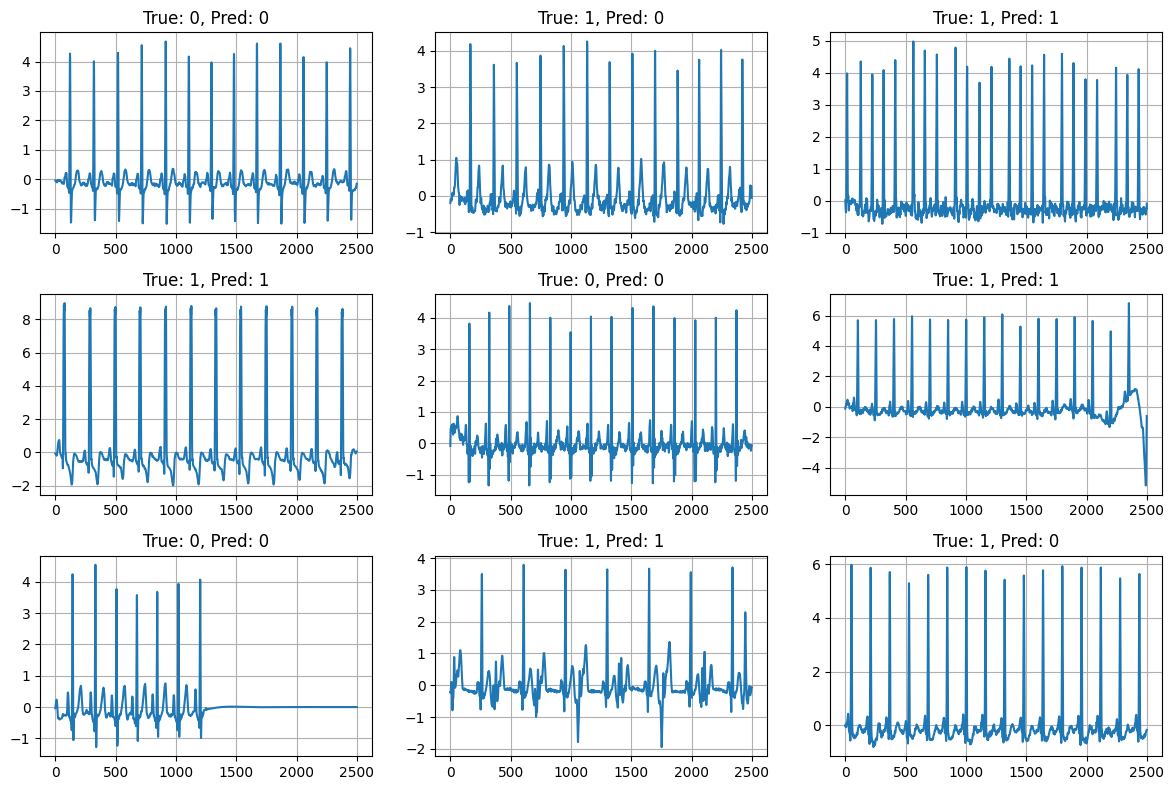

In [ ]:
bayes_model.eval()

X_batch, demog_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = bayes_model(X_batch.to(device), demog_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].cpu().numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()


## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


In [ ]:
'''
first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()
'''


'\nfirst_conv = ts_model.features[0]\nfilters = first_conv.weight.detach().cpu().numpy()\n\nplt.figure(figsize=(10, 6))\nfor i in range(filters.shape[0]):\n    plt.subplot(2, 4, i + 1)\n    plt.plot(filters[i, 0])\n    plt.title(f"Filter {i}")\n    plt.grid(True)\n\nplt.tight_layout()\nplt.show()\n'


# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.


## Classification Metrics

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

In [13]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

In [20]:
@torch.no_grad()
def collect_predictions_bayesian_nn_blitz(model, data_loader, device, n_samples=30):
    model.eval()
    model.to(device)

    all_y_true = []
    all_batch_probs_samples = [] # To store (S, B, K) for each batch

    for batch in data_loader:
        *inputs, y_batch = batch
        inputs = [x.to(device) for x in inputs]
        y_batch = y_batch.to(device)

        batch_size = y_batch.size(0)
        # Dynamically get num_classes from the model's output
        # Assuming the model returns logits (batch_size, num_classes)
        test_logits = model(*inputs)
        num_classes = test_logits.shape[1]

        probs_samples_batch = torch.zeros(n_samples, batch_size, num_classes, device=device)

        for i in range(n_samples):
            logits = model(*inputs)  # shape [batch, num_classes]
            probs = torch.softmax(logits, dim=1)  # (batch, num_classes)
            probs_samples_batch[i] = probs

        all_batch_probs_samples.append(probs_samples_batch.cpu().numpy())
        all_y_true.append(y_batch.cpu().numpy())

    y_test = np.concatenate(all_y_true)
    # Concatenate along the batch dimension (axis=1) to get (S, N, K)
    probs_samples = np.concatenate(all_batch_probs_samples, axis=1)
    probs_mean = probs_samples.mean(axis=0)  # (N, K)

    return {
        "probs_samples": probs_samples,
        "probs_mean": probs_mean,
        "y_test": y_test,
    }

## 5. Confusion matrix quantities

In [ ]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

In [ ]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

In [ ]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

In [ ]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

In [ ]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

In [ ]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

In [ ]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

In [ ]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

In [ ]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

In [ ]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):

    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

In [ ]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier (use later)

In [ ]:
def evaluate_bayesian_nn_classifier(model, guide, data_loader, device, num_samples=100, n_bins=10, dataset_size=None):
    y_true, probs, y_pred = collect_predictions_bayesian_nn(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        num_samples=num_samples,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["negative_elbo_per_example"] = estimate_negative_elbo_per_example_pyro(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        dataset_size=dataset_size,
    )

    metrics["num_posterior_prediction_samples"] = num_samples

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

In [19]:
results_dict = collect_predictions_bayesian_nn_blitz(
    model=bayes_model,
    data_loader=ts_test_loader,
    device=device,
    n_samples=100,
)

y_true_test = results_dict['y_test']
probs_mean = results_dict['probs_mean']
# For binary classification metrics, we often need P(class 1)
probs = probs_mean[:, 1]

y_pred = (probs >= 0.5).astype(int)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_true_test,
    probs=probs,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

NameError: name 'calculate_binary_classification_metrics' is not defined

Confusion matrix [[TN, FP], [FN, TP]]:
[[79 21]
 [26 74]]


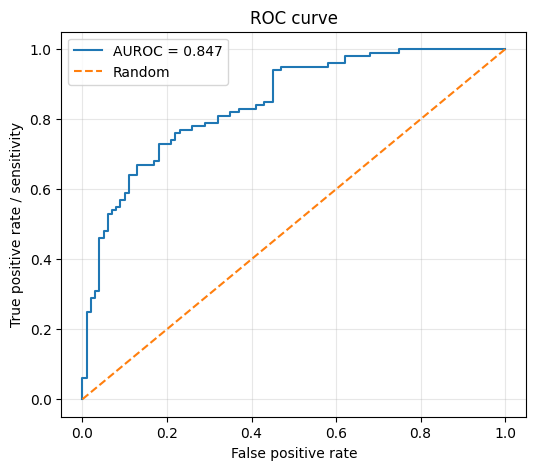

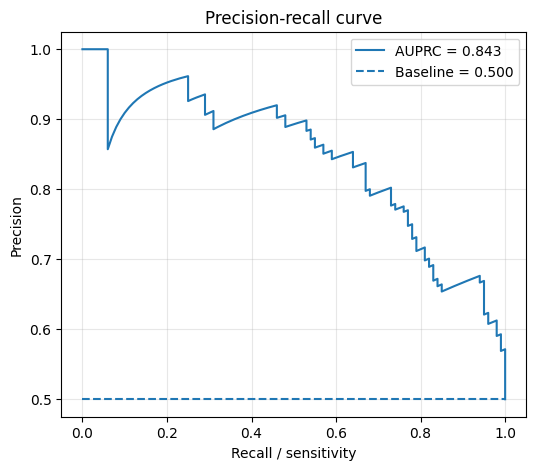

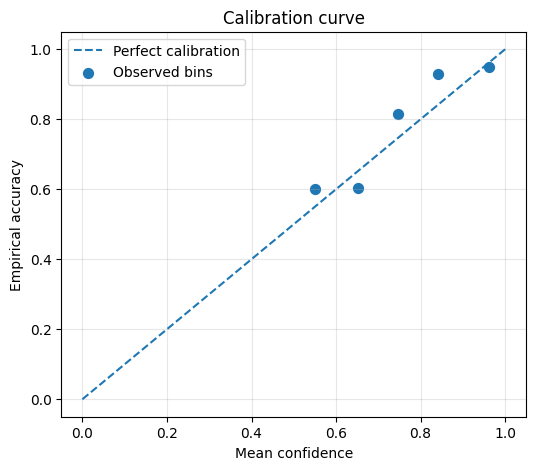

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,40,0.551347,0.600000,0.048653
6,7,0.6,0.7,43,0.651631,0.604651,0.046979
7,8,0.7,0.8,54,0.747586,0.814815,0.067229
8,9,0.8,0.9,43,0.840531,0.930233,0.089701
9,10,0.9,1.0,20,0.962041,0.950000,0.012041


In [ ]:

print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_true_test, y_pred, labels=[0, 1]))

plot_roc_curve(y_true_test, probs)
plot_precision_recall_curve(y_true_test, probs)
plot_calibration_curve(y_true_test, probs, n_bins=10)
calibration_table(y_true_test, probs, n_bins=10)


In [ ]:
from __future__ import annotations

import argparse
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score

try:
    from sklearn.metrics import confusion_matrix
except ImportError as exc:  # pragma: no cover
    raise SystemExit("This script needs scikit-learn: pip install scikit-learn") from exc

In [ ]:
df = pd.read_csv('EchoNext_EchoData_5K.csv')
le = LabelEncoder()
SHD = le.fit_transform(df['shd_moderate_or_greater_flag'].values.reshape(-1,1))
id    = le.fit_transform(df['split'].values.reshape(-1,1))
id_test  = np.where(id!=2)
n_test=2000
ytest = SHD[id_test][:n_test]

# print(np.shape(df))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
def load_npz(path: Path) -> dict[str, np.ndarray]:
    with np.load(path, allow_pickle=True) as data:
        return {key: data[key] for key in data.files}

In [ ]:
def normalize_probs(probs: np.ndarray) -> np.ndarray:
    """Return posterior probabilities as shape (S,N,K), or mean probs as (N,K)."""
    probs = np.asarray(probs)

    if probs.ndim == 1:
        return np.column_stack([1.0 - probs, probs])

    if probs.ndim == 2:
        # Ambiguous: either (S,N) binary posterior samples or (N,K) mean probs.
        # Caller decides by context. Here, if columns sum roughly to 1, treat as (N,K).
        row_sums = probs.sum(axis=1)
        if probs.shape[1] > 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        if probs.shape[1] == 2 and np.allclose(row_sums, 1.0, atol=1e-3):
            return probs
        # Otherwise binary posterior samples (S,N).
        return np.stack([1.0 - probs, probs], axis=-1)

    if probs.ndim == 3:
        if probs.shape[-1] == 1:
            p = probs[..., 0]
            return np.stack([1.0 - p, p], axis=-1)
        return probs

    raise ValueError(f"Expected probability array with ndim 1, 2, or 3; got shape {probs.shape}")

# Look at posterior probabilities for random test cases
def plot_random_class_probabilities_bayesian(
    results: dict[str, np.ndarray],
    posterior_probs: np.ndarray | None,
    num_classes: int,
    title: str,
    out_path: Path,
    dpi: int,
    n_random: int,
    seed: int,
    data_ids: np.ndarray | None
) -> None:

    ci_high_thresh = 0.2
    ci_low_thresh   = 0.5
    decision_out = ['No SHD','SHD','inconclusive']
    # if posterior_probs is None:
    #     print(
    #         f"[skip] {title}: posterior probability samples were not saved. "
    #         "Need probs_samples with shape (S, N, K) to plot PDFs."
    #     )
    #     return

    p = normalize_probs(posterior_probs)

    # if p.ndim != 3:
    #     print(f"[skip] {title}: posterior_probs could not be interpreted as shape (S,N,K).")
    #     return

    true_labels = None
    for key in ("y_true", "y_test", "true_class", "true_classes", "labels"):
        if key in results:
            true_labels = np.asarray(results[key])
            break

    n_samples, n_obs, inferred_num_classes = p.shape

    # if true_labels is not None and len(true_labels) != n_obs:
    #     print(
    #         f"[warning] {title}: found true labels with length {len(true_labels)}, "
    #         f"but posterior_probs has N={n_obs}. Not using true labels in titles."
    #     )
        # true_labels = None

    # if inferred_num_classes != num_classes:
    #     print(
    #         f"[warning] {title}: num_classes={num_classes}, "
    #         f"but posterior_probs has K={inferred_num_classes}. Using K={inferred_num_classes}."
    #     )
        # num_classes = inferred_num_classes

    rng = np.random.default_rng(seed)
    chosen = rng.choice(n_obs, size=min(n_random, n_obs), replace=False)
    if (len(data_ids)>0):
        chosen=rng.choice(data_ids, size=min(n_random, n_obs), replace=False)
    class_ids = np.arange(num_classes)
    for obs_idx in chosen:
        decision_plot = decision_out[0]
        BNN_pred = 0
        fig, ax = plt.subplots(figsize=(6, 4))
        for k in class_ids:
            vals = np.asarray(p[:, obs_idx, k], dtype=float)
            vals = vals[np.isfinite(vals)]

            if vals.size < 2:
                continue

            ax.hist(
                vals,
                bins=30,
                density=True,
                alpha=0.35,
                label=f"Class {decision_out[k]}",
            )

            mean_k = np.mean(vals)


            var_k  = np.var(vals)
            ci_low, ci_high = np.percentile(vals, [2.5, 97.5])
            if (k==1):
                if (ci_high<=ci_high_thresh):
                    decision_plot = decision_out[0]
                elif (ci_low>=ci_low_thresh):
                    decision_plot = decision_out[1]
                else:
                    decision_plot=decision_out[2]
                # print(f"sample {obs_idx} class {k} has ci_high={ci_high} and ci_low={ci_low}: decision:{decision_plot}")



            coeff_var = mean_k/np.sqrt(var_k)

            # ax.axvline(mean_k, linestyle="--", linewidth=1.5)


        if true_labels is not None:
            if (true_labels[obs_idx]==0):
                true_class_text = "True class: No SHD"
            else:
                true_class_text = "True class: SHD"
        else:
            true_class_text = "True class: unavailable"

        ax.set_xlim(0, 1)
        ax.set_xlabel("Class probability")
        ax.set_ylabel("Posterior density")
        ax.axvline(ci_low_thresh, color='r',linestyle="--", linewidth=2.0,label='threshold: SHD')
        ax.axvline(ci_high_thresh, color='m',linestyle="--", linewidth=2.0, label='threshold: no SHD')
        ax.set_title(
            f"{title}\n"
            f"Test sample {obs_idx} | {true_class_text}\n"
            f"Decision: {decision_plot}"
        )
        ax.grid(True, alpha=0.10)
        ax.legend(loc="best")

        fig.tight_layout()

        sample_out_path = f"{out_path}_sample_{obs_idx}_pdfs.png"
        fig.savefig(sample_out_path, dpi=dpi)
        # plt.close(fig)

        # print(f"[saved] {sample_out_path}")

In [ ]:
import numpy as np
import torch

@torch.no_grad()
def collect_posterior_samples_late_fusion(model, data_loader, device, n_samples=50):
    """
    Runs n_samples stochastic forward passes of the Bayesian late-fusion model
    over the entire data_loader, and returns a dict compatible with
    plot_random_class_probabilities_bayesian.

    Returns
    -------
    results : dict with keys
        'probs_samples' : (S, N, K) array of per-sample softmax probabilities
        'probs_mean'    : (N, K) array of mean probabilities across samples
        'y_test'        : (N,) array of true labels
    """
    model.eval()  # BLiTZ layers still sample weights even in eval mode
    model.to(device)

    all_y_true = []
    all_ts = []
    all_demo = []

    # First, collect all data once (so we don't reload the loader n_samples times)
    for X_ts_b, X_demo_b, y_b in data_loader:
        all_ts.append(X_ts_b)
        all_demo.append(X_demo_b)
        all_y_true.append(y_b)

    X_ts_all = torch.cat(all_ts, dim=0).to(device)
    X_demo_all = torch.cat(all_demo, dim=0).to(device)
    y_true = torch.cat(all_y_true, dim=0).cpu().numpy()

    N = X_ts_all.shape[0]
    num_classes = 2  # binary classification

    probs_samples = np.zeros((n_samples, N, num_classes), dtype=np.float32)

    for s in range(n_samples):
        logits = model(X_ts_all, X_demo_all)          # (N, num_classes)
        probs = torch.softmax(logits, dim=1)          # (N, num_classes)
        probs_samples[s] = probs.cpu().numpy()

    probs_mean = probs_samples.mean(axis=0)  # (N, num_classes)

    return {
        "probs_samples": probs_samples,
        "probs_mean": probs_mean,
        "y_test": y_true,
    }

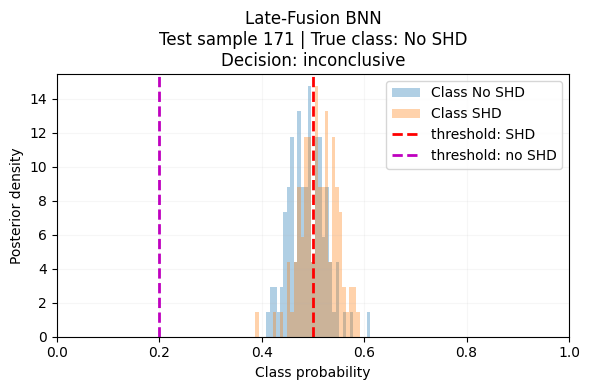

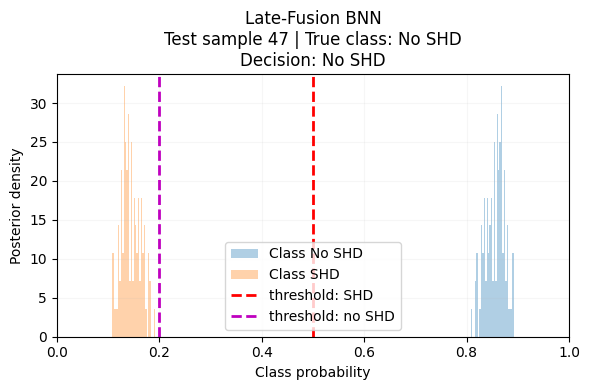

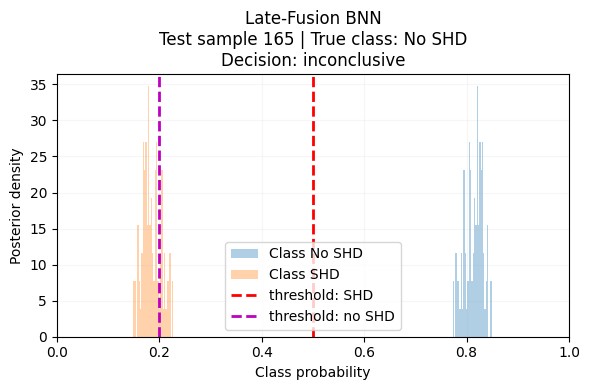

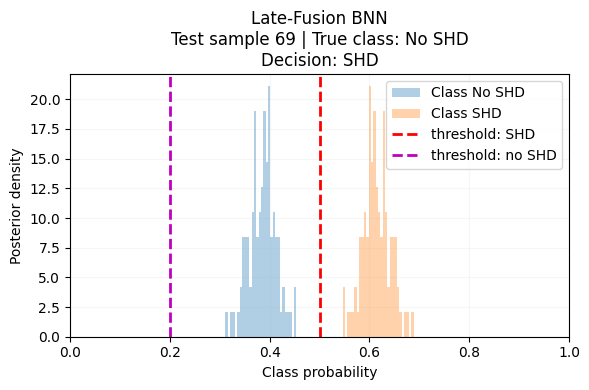

In [ ]:
from pathlib import Path

# Create the directory if it doesn't exist
output_dir = Path('PaperFigures')
output_dir.mkdir(parents=True, exist_ok=True)

BNN_results_latefusion = collect_posterior_samples_late_fusion(
    model=bayes_model,          # your trained BayesianLateFusionHeartDiseaseModel
    data_loader=ts_test_loader,
    device=device,
    n_samples=100,
)

plot_random_class_probabilities_bayesian(
    results=BNN_results_latefusion,
    posterior_probs=BNN_results_latefusion['probs_samples'],
    num_classes=2,
    title='Late-Fusion BNN',
    out_path='PaperFigures/BNN_latefusion',
    dpi=200,
    n_random=4,
    seed=108,
    data_ids=np.arange(len(BNN_results_latefusion['y_test']))  # or a specific subset like probs_id[1000:]
)

In [ ]:
import numpy as np
import pandas as pd

def calculate_true_class_credible_intervals(results, ci=95):
    """
    Compute posterior statistics for the TRUE class probability of each patient.

    Returns
    -------
    DataFrame with:
        Patient
        True Label
        Predicted Label
        Correct Prediction
        Posterior Mean (True Class)
        Posterior Std
        95% CrI Lower
        95% CrI Upper
        CrI Width
    """

    probs_samples = results["probs_samples"]      # (S, N, 2)
    probs_mean = results["probs_mean"]            # (N, 2)
    y_true = np.asarray(results["y_test"])

    alpha = (100 - ci) / 2

    rows = []

    for i in range(len(y_true)):

        true_class = int(y_true[i])

        # Prediction from posterior mean probabilities
        pred_class = int(np.argmax(probs_mean[i]))

        # Posterior samples for the TRUE class
        samples = probs_samples[:, i, true_class]

        posterior_mean = samples.mean()
        posterior_std = samples.std()

        ci_lower = np.percentile(samples, alpha)
        ci_upper = np.percentile(samples, 100 - alpha)

        rows.append({
            "Patient": i,
            "True Label": true_class,
            "Predicted Label": pred_class,
            "Correct": pred_class == true_class,
            "Posterior Mean (True Class)": posterior_mean,
            "Posterior Std": posterior_std,
            f"{ci}% CrI Lower": ci_lower,
            f"{ci}% CrI Upper": ci_upper,
            "CrI Width": ci_upper - ci_lower,
        })

    return pd.DataFrame(rows)

In [ ]:
true_class_df = calculate_true_class_credible_intervals(BNN_results_latefusion)

true_class_df.head(10)

,Patient,True Label,Predicted Label,Correct,Posterior Mean (True Class),Posterior Std,95% CrI Lower,95% CrI Upper,CrI Width
0,0,0,0,True,0.520274,0.040089,0.447322,0.599402,0.152079
1,1,1,0,False,0.356932,0.036771,0.280518,0.428295,0.147777
2,2,1,1,True,0.803607,0.045998,0.696624,0.869737,0.173113
3,3,1,1,True,0.806344,0.036321,0.730399,0.863914,0.133515
4,4,0,0,True,0.711465,0.017311,0.680270,0.743806,0.063536
5,5,1,1,True,0.846415,0.026488,0.788739,0.890936,0.102197
6,6,0,0,True,0.536160,0.018224,0.502742,0.568167,0.065425
7,7,1,1,True,0.972109,0.007052,0.958002,0.982594,0.024592
8,8,1,0,False,0.487020,0.046708,0.400284,0.588264,0.187980
9,9,0,0,True,0.731524,0.014411,0.697844,0.757185,0.059341


In [ ]:
latebcnn_ytest = y_true_test
latebcnn_probs = probs